# Mini-Projeto Avaliativo — Módulo 2
## Desenvolvimento de IA para Análise Preditiva — Classificação de dígitos manuscritos (MNIST)

**Autor:** <seu nome>

Este notebook está segmentado nas Fases e Desafios exigidos no enunciado. Cada seção
tem uma célula de texto justificando as decisões técnicas e as células de código
correspondentes.


---
## Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

**O que esta fase precisa entregar (critério 4):**
1. Carregar o MNIST (`fetch_openml('mnist_784')`)
2. Exibir a dimensionalidade de `X` e `y`
3. Comprovar a distribuição das classes (balanceamento dos dígitos 0–9)
4. Grade visual de no mínimo 2×5 com um exemplo de cada dígito + rótulo
5. Célula de texto interpretando a estrutura dos dados (escala 0–255, imagem 28×28 → vetor de 784)


### 1.1 — Imports

In [2]:
# TODO: importe numpy, pandas, matplotlib.pyplot, seaborn e fetch_openml aqui
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml

### 1.2 — Carregamento do dataset

In [3]:
# TODO: carregue o MNIST com fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
# Lembre: o y volta como STRING -> converta para inteiro (ex: y = y.astype(np.uint8))
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target
y = y.astype(np.uint8)  

### 1.3 — Dimensionalidade dos dados

In [4]:
# TODO: imprima X.shape, y.shape, X.dtype, X.min(), X.max()
# Comente (célula de texto abaixo) o que cada dimensão significa
print(X.shape, y.shape, X.dtype, X.min(), X.max())

(70000, 784) (70000,) int64 0 255


- O dataset tem 70.000 imagens; cada uma é descrita por 784 valores.
- Esses 784 vêm de imagens 28×28 pixels achatadas em vetor (28*28 = 784).
- y tem 70.000 rótulos, um dígito de 0 a 9 por imagem.
- Os pixels vão de 0 (preto) a 255 (branco), em 8 bits, ainda sem normalização.

### 1.4 — Distribuição das classes

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


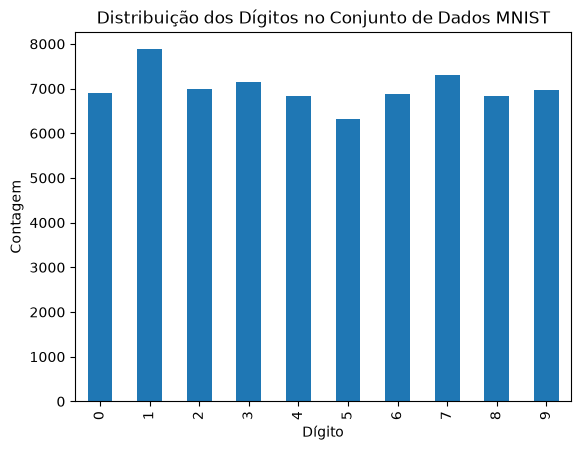

In [5]:
# TODO: conte quantas amostras existem por dígito (np.unique(..., return_counts=True)
#       ou pd.Series(y).value_counts().sort_index())
# TODO: plote um gráfico de barras (contagem por dígito 0-9)
pd.Series(y).value_counts().sort_index().plot(kind='bar')
print(pd.Series(y).value_counts().sort_index())
plt.xlabel('Dígito')
plt.ylabel('Contagem')
plt.title('Distribuição dos Dígitos no Conjunto de Dados MNIST')
plt.show()

- O dataset está balanceado. A diferença entre a classe mais e menos frequente é de ~20%, o que caracteriza um dataset balanceado. Por isso a acurácia global é uma métrica confiável neste problema; ainda assim vamos acompanhar precision/recall/F1 por classe.

### 1.5 — Grade visual dos dígitos (mínimo 2×5)

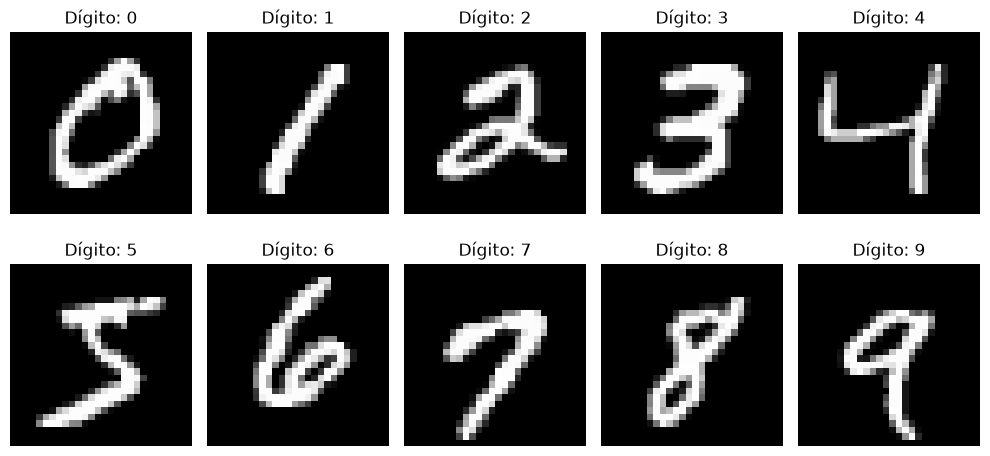

In [6]:
# TODO: plt.subplots(2, 5); para cada dígito d de 0 a 9, pegue o primeiro índice onde y == d,
#       faça reshape(28, 28), plote com cmap='gray', axis('off') e título = rótulo
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for d in range(10):
    idx = np.where(y == d)[0][0]  # Primeiro índice onde y == d
    img = X[idx].reshape(28, 28)  # Reshape para 28x28
    ax = axes[d // 5, d % 5]  # Seleciona o subplot correto
    ax.imshow(img, cmap='gray')  # Plota a imagem em escala de cinza
    ax.axis('off')  # Desliga os eixos
    ax.set_title(f'Dígito: {d}')  # Define o título como o dígito correspondente
plt.tight_layout()
plt.show()  

### 1.6 — Interpretação da estrutura dos dados

**1. Escala de pixel 0–255:**

* Cada quadradinho (pixel) guarda um número entre 0 e 255 para mostrar o seu brilho: 0 é o preto absoluto, 
255 é o branco puro e os números do meio são os vários tons de cinza (do mais escuro ao mais claro). Como só usamos essa variação de brilho, a imagem tem apenas 1 canal (escala de cinza). É diferente de uma foto colorida comum, que precisa misturar 3 canais de cores (Vermelho, Verde e Azul) para formar a imagem.

**2. De 28×28 para 784 (flatten):**

* Imagine que a imagem original é um quadrado formado por um quadriculado de 28 fileiras de altura por 28 fileiras de largura, somando 784 quadradinhos (pixels). Para que modelos tradicionais de inteligência artificial consigam ler essa imagem, fazemos o seguinte, recortamos linha por linha da imagem e colocamos todas em uma única fila reta. Isso transforma a imagem em uma linha comprida com 784 pontos de informação. Cada ponto dessa fila indica apenas o quão claro ou escuro é aquele ponto específico da imagem..

**3. O que se perde:**

* Quando colocamos todos os quadradinhos em uma única fila (o chamado flatten), a imagem perde o seu "mapa" e o modelo "esquece" o formato original, ele não percebe mais quais pedacinhos ficavam um em cima do outro. Para ele, agora são apenas 784 números misturados. Modelos comuns só olham posições fixas, eles aprendem apenas o que acontece em cada ponto isolado da fila. Redes Neurais de Imagens (CNNs) são diferentes, elas conseguem olhar para a imagem sem desmontar o quadrado, entendendo como cada pedaço se conecta aos seus vizinhos do lado, de cima e de baixo.


---
## Fase 2 — Pipeline de Pré-processamento e Divisão dos Dados (Preenchimento na branch da Fase 2).

### 2.1 — Divisão Estratificada: Treino, Validação e Teste

A base é dividida em três conjuntos, na proporção **70% treino / 10% validação / 20% teste**,
usando `train_test_split` em duas etapas:

* **1ª divisão:** separa 20% para o conjunto de teste.

* **2ª divisão:** do restante (80%), separa 12,5% para validação (equivale a 10% do total).

Em ambas as etapas usamos "stratify" para preservar a proporção dos dígitos 0–9 em cada
conjunto, e "random_state=42" para garantir reprodutibilidade.

In [9]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print("Treino:   ", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:    ", X_test.shape, y_test.shape)



Treino:    (49000, 784) (49000,)
Validação: (7000, 784) (7000,)
Teste:     (14000, 784) (14000,)


## 2.2 — Normalização dos Pixels

### Dividir o valor de cada quadradinho por 255.0 muda a sua escala de 0 a 255 para 0.0 a 1.0:

* É simples e direto: Usamos o número 255 porque ele é a regra fixa das imagens (o brilho máximo de um pixel nunca passa disso).

* Evita "cola" no treino (vazamento de dados): Outras técnicas de ajuste precisam analisar todos os dados do treino para descobrir os valores máximos ou a média. A divisão direta por 255 não precisa olhar nada — ela usa uma regra fixa e garante que as informações de teste continuem 100% secretas antes da hora.

In [8]:
# Normalização: divide cada pixel por 255.0 para que os valores fiquem entre 0 e 1.
X_train = X_train / 255.0
X_val   = X_val / 255.0
X_test  = X_test / 255.0
print("Min:", X_train.min(), "| Max:", X_train.max())
print("Min:", X_val.min(), "| Max:", X_val.max())
print("Min:", X_test.min(), "| Max:", X_test.max())

Min: 0.0 | Max: 1.0
Min: 0.0 | Max: 1.0
Min: 0.0 | Max: 1.0


## 2.3. Justificativas Técnicas das Decisões
### Por que estratificar a divisão?

Para garantir que o modelo receba a mesma proporção de cada grupo (por exemplo, a mesma quantidade de números de 0 a 9) no treino, na validação e no teste. Sem isso, o teste poderia ficar sem nenhuma foto de algum número específico e o resultado seria injusto.

### Por que normalizar os dados?

Em vez de usar números grandes de 0 a 255, transformamos tudo para uma escala simples entre 0 e 1. Isso impede que números maiores "puxem a atenção" do modelo sem necessidade e faz com que ele aprenda muito mais rápido e sem se confundir.

### Por que separar Validação e Teste?

Validação (os ensaios do dia a dia): Serve para fazer testes do dia a dia, ajustar configurações e ver qual versão do modelo funciona melhor.

Teste (a prova final): É um grupo de dados guardado que o modelo nunca viu. Ele só é usado no final de tudo para mostrar a nota real do modelo com problemas da vida real.

---
## Fase 3 — Implementação e Treinamento dos 3 Modelos

*(a preencher na branch da Fase 3 — modelos escolhidos: <preencher>)*


---
## Fase 4 — Avaliação Comparativa de Desempenho

*(a preencher na branch da Fase 4)*


---
## Fase 5.1 — Desafio (A): Treinamento Restrito com Classes Ocultadas (Class Masking)

*(a preencher)*


---
## Fase 5.2 — Desafio (B): Teste de Generalização Extrema (Inferência OOD)

*(a preencher)*


---
## Fase 5.3 — Desafio (C): Inferência com Imagens Manuscritas Próprias

*(a preencher — imagens em `data/`)*
